# Demonstrate how to convert healpix to lat/lon and then to iris cube

* Computes number of latitude and longitude points equating to input zoom (or define an analysis grid)
* Uses nearest neighbour interpolation.
* Plots the results using iris plotting.

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr
import iris
import iris.plot as iplt
import iris.quickplot as qplt

from utils import hp_mods, plot_all_fields

In [3]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [4]:
# Define function to compute number of latitude and longitude points appropriate for each Healpix zoom
# For more approximate computation, nlon ~ 4*nside; nlat ~ 3*nside
def healpix_zoom_to_grid_area_match(zoom):
    nside = 2.0**zoom

    # Healpix pixel area
    pixel_area = 4 * np.pi / (12 * nside**2)

    # Angular resolution
    theta = np.sqrt(pixel_area)

    # Compute nlon, nlat
    nlon = int(round(2 * np.pi / theta))
    nlat = int(round(np.pi / theta))

    return nlon, nlat

In [5]:
# Define function to translate from healpix to lat lon [could sit in utils.py, but showing here for transparency]
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("latitude", lats), ("longitude", lons)],
    )

In [6]:
# Define a function to generate iris cube from xarray Dataset
def xarray_to_iris(dataset, varname):
    
    # Convert from xarray to iris cube
    cube = dataset[varname].to_iris()

    # Add more metadata to lat and lon coords
    for cube_coord in ["latitude", "longitude"]:
        cube.coord(cube_coord).units="degrees"
        cube.coord(cube_coord).coord_system=iris.coord_systems.GeogCS(6371229.0)
        cube.coord(cube_coord).guess_bounds()
        
    # Remove crs coord
    cube.remove_coord("crs")
    
    # Rename index coord
    cube.coord("healpix_index").rename("cell")

    # Set standard_calendar for time coord
    cube.coord("time").units = cube.coord("time").units.change_calendar("standard")

    return cube

In [7]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [8]:
# Print all catalog entries
print([k for k in cat])

['CERES_EBAF', 'ERA5', 'IR_IMERG', 'JRA3Q', 'MERRA2', 'arp-gem-1p3km', 'arp-gem-2p6km', 'casesm2_10km_nocumulus', 'icon_d3hp003', 'icon_d3hp003aug', 'icon_d3hp003feb', 'icon_ngc4008', 'ifs_tco3999-ng5_deepoff', 'ifs_tco3999-ng5_rcbmf', 'ifs_tco3999-ng5_rcbmf_cf', 'ifs_tco3999_rcbmf', 'nicam_220m_test', 'nicam_gl11', 'scream-dkrz', 'tracking-d3hp003', 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest', 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_glm_n1280_CoMA9_TBv1p2', 'um_glm_n1280_CoMA9_hk26', 'um_glm_n1280_GAL9', 'um_glm_n12

In [9]:
# Print all hk26 catalog entries
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [10]:
# Load specific model
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat = cat()[sim]

In [11]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_lr = 2
ds1h_lr = sim_cat(zoom=zoom_lr, time='PT1H').to_dask().pipe(hp_mods)
ds3h_lr = sim_cat(zoom=zoom_lr, time='PT3H').to_dask().pipe(hp_mods)

In [12]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_hr = 8
ds1h_hr = sim_cat(zoom=zoom_hr, time='PT1H').to_dask().pipe(hp_mods)
ds3h_hr = sim_cat(zoom=zoom_hr, time='PT3H').to_dask().pipe(hp_mods)

In [62]:
# OPTION A: Define an analyisis grid (e.g. 1 degree global) - used to output all zoom levels to same analysis grid.
#           Caution uses nearest neighbour interpolation. May be useful for exploring data and testing ideas, or 
#           where matching to e.g. observations grid.
#           Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified
import ast
domain_bounds = ast.literal_eval(ds1h_hr.attrs.get("regional_bounds"))
lon1 = domain_bounds["lower_left_lon"]
lon2 = domain_bounds["upper_right_lon"]
nlon = 360
lons = np.linspace(lon1, lon2, nlon)

lat1 = domain_bounds["lower_left_lat"]
lat2 = domain_bounds["upper_right_lat"]
nlat = 180
lats = np.linspace(lat1, lat2, nlat)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons, lats)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons, lats)

In [63]:
len(idx_lr)

180

In [64]:
len(idx_hr)

180

In [65]:
ds1h_lr_latlon = ds1h_lr.isel(cell=idx_lr)
ds1h_hr_latlon = ds1h_hr.isel(cell=idx_hr)

ds3h_lr_latlon = ds3h_lr.isel(cell=idx_lr)
ds3h_hr_latlon = ds3h_hr.isel(cell=idx_hr)

In [46]:
ds1h_lr_latlon

<xarray.Dataset> Size: 76GB
Dimensions:    (time: 9745, latitude: 180, longitude: 360, depth: 4)
Coordinates:
  * time       (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * latitude   (latitude) float64 1kB -90.0 -88.99 -87.99 ... 87.99 88.99 90.0
  * longitude  (longitude) float64 3kB 0.0 1.003 2.006 ... 358.0 359.0 360.0
    cell       (latitude, longitude) int64 518kB 128 128 128 128 ... 63 63 63 15
    lat        (latitude, longitude) float64 518kB -78.28 -78.28 ... 78.28 78.28
    lon        (latitude, longitude) float64 518kB 45.0 45.0 45.0 ... 315.0 45.0
  * depth      (depth) float32 16B 0.05 0.225 0.675 2.0
    crs        int64 8B 0
Data variables: (12/29)
    clivi      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    clt        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    clwvi      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    hflso      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    hfsso      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    huss       (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    ...         ...
    rsutcs     (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    sftlf      (latitude, longitude) float64 518kB dask.array<chunksize=(1, 180), meta=np.ndarray>
    tas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    ts         (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    uas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    vas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [47]:
ds1h_lr_latlon["cell"].attrs.pop("standard_name", None)
temp_cube_latlon_lr_A = ds1h_lr_latlon["tas"].to_iris()

In [48]:
ds1h_hr_latlon["cell"].attrs.pop("standard_name", None)
temp_cube_latlon_hr_A = ds1h_hr_latlon["tas"].to_iris()

In [49]:
temp_cube_latlon_lr_A

Air Temperature (K),time,latitude,longitude
Shape,9745,180,360
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x
Auxiliary coordinates,,,
cell,-,x,x
latitude,-,x,x
longitude,-,x,x
Scalar coordinates,,,


In [50]:
temp_cube_latlon_hr_A

Air Temperature (K),time,latitude,longitude
Shape,9745,180,360
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x
Auxiliary coordinates,,,
cell,-,x,x
latitude,-,x,x
longitude,-,x,x
Scalar coordinates,,,


/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'longitude' is not bounded, guessing contiguous bounds.
  warnings.warn(
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'latitude' is not bounded, guessing contiguous bounds.
  warnings.warn(


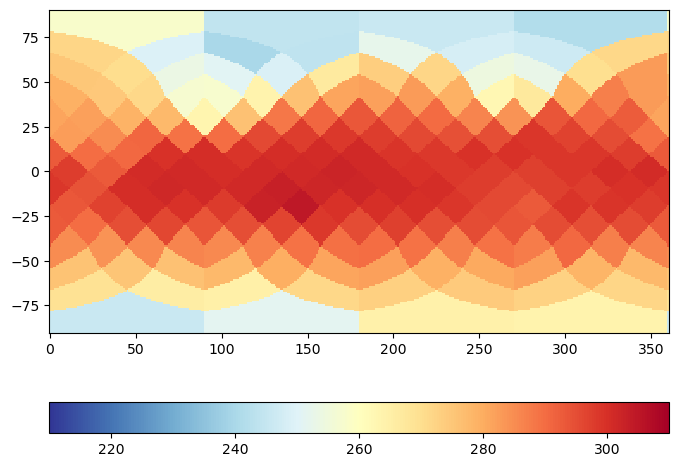

In [51]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_lr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

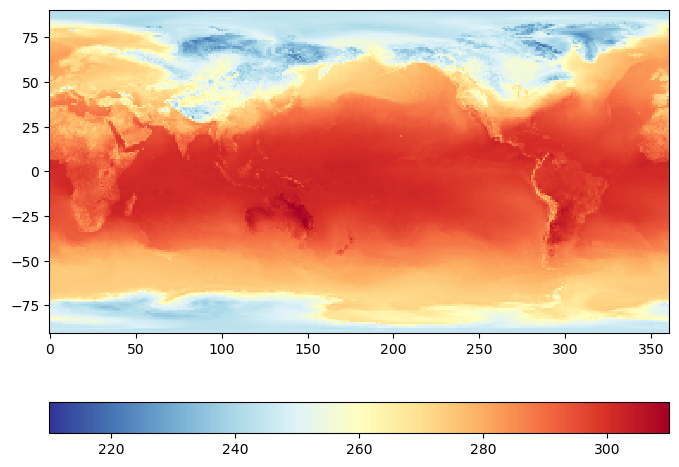

In [52]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_hr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

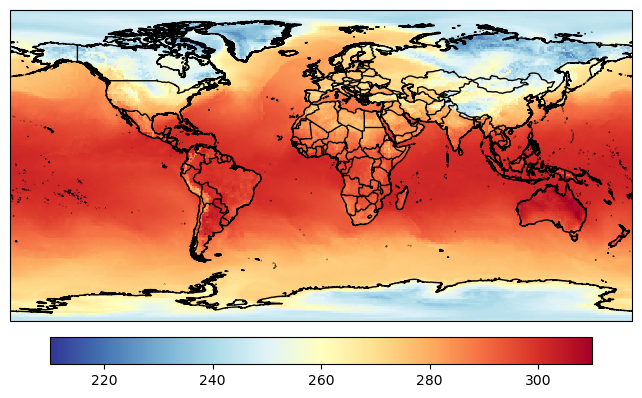

In [53]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_hr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'longitude' is not bounded, guessing contiguous bounds.
  warnings.warn(
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'latitude' is not bounded, guessing contiguous bounds.
  warnings.warn(


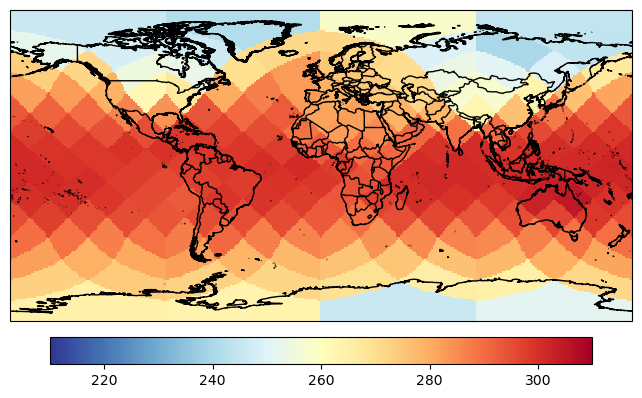

In [54]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_lr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

In [58]:
# OPTION B: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]
#          Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified
domain_bounds = ast.literal_eval(ds1h_hr.attrs.get("regional_bounds"))
lon1 = -180 #domain_bounds["lower_left_lon"]
lon2 = 180 #domain_bounds["upper_right_lon"]
lat1 = -90 #domain_bounds["lower_left_lat"]
lat2 = 90 #domain_bounds["upper_right_lat"]

# Call function to compute nlon, nlat based on zoom level
nlon_lr, nlat_lr = healpix_zoom_to_grid_area_match(zoom_lr) #, lat1, lat2, lon1, lon2)
lons_lr = np.linspace(lon1, lon2, nlon_lr)
lats_lr = np.linspace(lat1, lat2, nlat_lr)

nlon_hr, nlat_hr = healpix_zoom_to_grid_area_match(zoom_hr) #, lat1, lat2, lon1, lon2)
lons_hr = np.linspace(lon1, lon2, nlon_hr)
lats_hr = np.linspace(lat1, lat2, nlat_hr)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons_lr, lats_lr)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons_hr, lats_hr)

In [59]:
len(idx_lr)

12

In [60]:
len(idx_hr)

786

In [56]:
ds1h_lr_latlon = ds1h_lr.isel(cell=idx_lr)
ds1h_hr_latlon = ds1h_hr.isel(cell=idx_hr)

ds3h_lr_latlon = ds3h_lr.isel(cell=idx_lr)
ds3h_hr_latlon = ds3h_hr.isel(cell=idx_hr)

In [30]:
ds1h_lr_latlon["cell"].attrs.pop("standard_name", None)
temp_cube_latlon_lr_B = ds1h_lr_latlon["tas"].to_iris()

In [31]:
ds1h_hr_latlon["cell"].attrs.pop("standard_name", None)
temp_cube_latlon_hr_B = ds1h_hr_latlon["tas"].to_iris()

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'longitude' is not bounded, guessing contiguous bounds.
  warnings.warn(
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2122: IrisGuessBoundsWarning: Coordinate 'latitude' is not bounded, guessing contiguous bounds.
  warnings.warn(


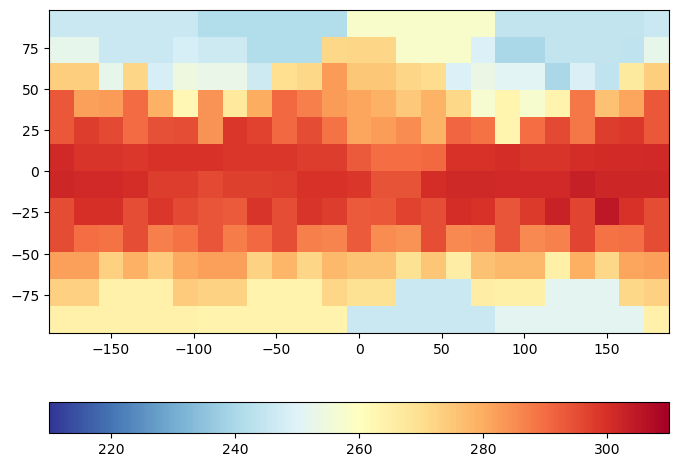

In [32]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_lr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

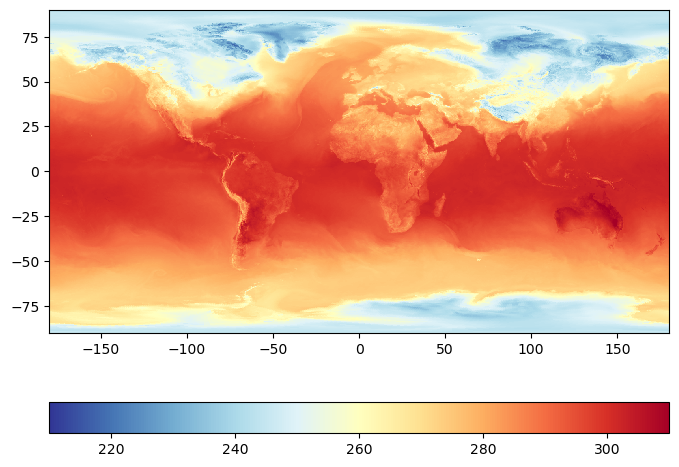

In [33]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_hr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

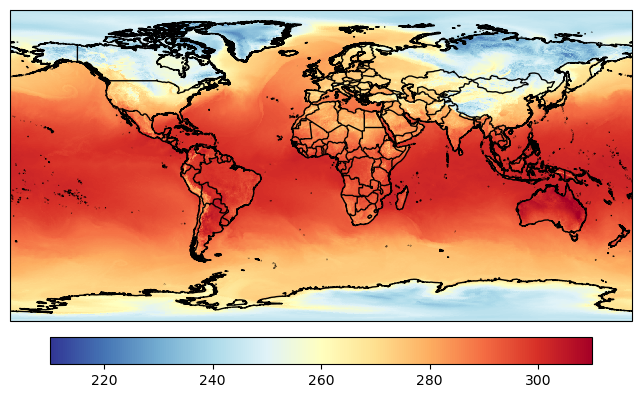

In [34]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_hr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

In [ ]:
# OPTION 1: Define an analyisis grid (e.g. 1 degree global) - used to output all zoom levels to same analysis grid.
#           Caution uses nearest neighbour interpolation. May be useful for exploring data and testing ideas, or 
#           where matching to e.g. observations grid.
lon1 = 0
lon2 = 360
nlon = 360
lons = np.linspace(lon1, lon2, nlon)

lat1 = -90
lat2 = 90
nlat = 180
lats = np.linspace(lat1, lat2, nlat)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons, lats)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons, lats)

In [ ]:
# OPTION2: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]

# Call function to compute nlon, nlat based on zoom level
nlon_lr, nlat_lr = healpix_zoom_to_grid_area_match(zoom_lr)
lons_lr = np.linspace(0, 360, nlon_lr)
lats_lr = np.linspace(-90, 90, nlat_lr)

nlon_hr, nlat_hr = healpix_zoom_to_grid_area_match(zoom_hr)
lons_hr = np.linspace(0, 360, nlon_hr)
lats_hr = np.linspace(-90, 90, nlat_hr)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons_lr, lats_lr)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons_hr, lats_hr)

In [ ]:
# Reorganise 1hr xarray 1d Dataset to 2d Dataset with lat/lon dimensions
ds1h_lr_latlon = ds1h_lr.isel(healpix_index=idx_lr)
ds1h_hr_latlon = ds1h_hr.isel(healpix_index=idx_hr)

ds3h_lr_latlon = ds3h_lr.isel(healpix_index=idx_lr)
ds3h_hr_latlon = ds3h_hr.isel(healpix_index=idx_hr)

In [ ]:
ds3h_lr_latlon

In [ ]:
# Check sample regridded xarray variable output (hi-res)
ds1h_hr_latlon.isel(time=1).pr.plot()

In [ ]:
# Check sample regridded xarray variable output (lo-res)
ds1h_lr_latlon.isel(time=1).pr.plot()

In [ ]:
# Check sample regridded 3hr xarray variable output (hi-res)
ds3h_hr_latlon.isel(time=1).sel(pressure=850).ua.plot()

In [ ]:
# Check sample regridded 3hr xarray variable output (lo-res)
ds3h_lr_latlon.isel(time=1).sel(pressure=850).ua.plot()

In [ ]:
# Convert from xarray to iris cube
temp_hr_cube = xarray_to_iris(ds1h_hr_latlon, "tas")
temp_lr_cube = xarray_to_iris(ds1h_lr_latlon, "tas")

In [ ]:
temp_hr_cube

In [ ]:
# Use iris quickplot for quick-look plot
qplt.pcolormesh(temp_hr_cube[1],cmap='RdYlBu_r')

In [ ]:
# Use iris quickplot for quick-look plot
qplt.pcolormesh(temp_lr_cube[1],cmap='RdYlBu_r')

In [ ]:
# Use iris analysis to compute global average timeseries (only compute for lo-res input given global mean output)
t_mean = temp_lr_cube.collapsed(["latitude","longitude"], iris.analysis.MEAN)
qplt.plot(t_mean)

In [ ]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_hr_cube[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

In [ ]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_hr_cube[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

In [ ]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(cube_2d[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)